# Training and Fine-Tuning BERT for Classification
## Classfying Goodreads Reviews By Book Genre

By Maria Antoniak, Melanie Walsh, and the [AI for Humanists](https://aiforhumanists.com/) Team

Updated: 2024-11-05
<br></br>

This notebook will demonstrate how users can train and fine-tune a BERT model for classification with the popular HuggingFace `transformers` Python library.

We will fine-tune a BERT model on Goodreads reviews from the [UCSD Book Graph](https://mengtingwan.github.io/data/goodreads.html) with the goal of predicting the genre of the book being reviewed. The genres include:
- poetry
- comics & graphic
- fantasy & paranormal
- history & biography
- mystery, thriller, & crime
- romance
- young adult  

**Basic steps involved in using BERT and HuggingFace:**
1. Divide your data into training and test sets.
2. Encode your data into a format BERT will understand.
3. Combine your data and labels into datset objects.
4. Load the pre-trained BERT model.
5. Fine-tune the model using your training data.
6. Predict new labels and evaluate performance on your test data.



<br><br>

## **Import necessary Python libraries and modules**

First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

In [1]:
!pip3 install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.8/668.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 82.7 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

From `transformers`, we will import modules for `DistilBert`, a *distilled* or smaller version of a BERT model that runs more quickly and uses less computing power. This makes it ideal for those just getting started with BERT.

In [3]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

<br><br>

## **Set parameters and file paths**

In [4]:
# This is the name of the BERT model that we want to use.
# We're using DistilBERT to save space (it's a distilled version of the full BERT model),
# and we're going to use the cased (vs uncased) version.
model_name = 'distilbert-base-cased'

# This is the name of the program management system for NVIDIA GPUs. We're going to send our code here.
device_name = 'cuda'

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'distilbert-reviews-genres'

<br><br>

## **Load and sample Goodreads data**

In this cell, we create a Python dictionary with each genre and the link to the corresponding UCSD Goodreads review data for that genre.

*If you manually click on any of the URLs, you will be able to download the data for that genre. For example, here's the link for poetry: https://datarepo.eng.ucsd.edu/mcauley_group/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz*

In [5]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

Next we loop through this dictionary and use `gdown` to download the Goodreads review data for each genre from Google Drive.

Now we will load the first 100,000 reviews from each link and randomly sample 2,000 reviews.

In [6]:
import requests
# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the 100,000 limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry
<Response [200]>
Loading reviews for genre: children
<Response [200]>
Loading reviews for genre: comics_graphic
<Response [200]>
Loading reviews for genre: fantasy_paranormal
<Response [200]>
Loading reviews for genre: history_biography
<Response [200]>
Loading reviews for genre: mystery_thriller_crime
<Response [200]>
Loading reviews for genre: romance
<Response [200]>
Loading reviews for genre: young_adult
<Response [200]>


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [7]:
 for _genre, _reviews in genre_reviews_dict.items():
    print(_genre)
    print(random.sample(_reviews, 1)[0])

poetry
I loved Patti's writing style as usual, she is the MASTER of imagery. Her writing is iconic for me. But after Just Kids and M Train, I wasn't nearly as into this collection. Still a stellar bunch of pieces honestly. She does capture the dreamy essence of childhood beautifully.
children
A fun fight of Mine! 
 Good for toddler or preschool storytimes.
comics_graphic
Shorts. The X-51 that leads things off is at best semi-comprehensible with some good effort at variant storytelling [4/10]. The X-Men Annual is a more readable if mediocre story [5/10]. 
 Ages of Apocalypse. I just don't understand the purpose of these shorts. Are they supposed to flow together? Are they supposed to be one-offs? In any case, they feel totally irrelevant and unimportant [3/10]. 
 The Search for Cyclops. Certainly the best-written of the stories in this volume, with great art and nice dialogue ... but the plot drags horribly, pretty much wasting three and a half issues solely to get to the big fight at t

Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.

*The `pickle` module allows you to save and load Python objects like lists and dictionaries.*

In [8]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

<br><br>

## **Split the data into training and test sets**

When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our BERT model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.

In [9]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

In [10]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

Here's an example of a training label and review:

In [11]:
train_labels[0], train_texts[0]

('poetry',
 "After reading this in high school, I had the opportunity to see the National Shakespeare Company perform it at The Globe theater in Odessa, TX. which was quite an experience, one that I hope to repeat some day. There's just something special about seeing a play in proper context that really makes it great. I laughed out loud. \n And it made me come to a realization about a lot of Shakespeare's work that I think too many literary scholars forget or choose to ignore and that is the fact that these works they adore are meant first and foremost to be performed before a live audience and in searching for hidden meanings and subtle linguistic tricks and rhyming schemes it becomes clear that those elements are present only when the plays are read silently and not at all when they are spoken openly. Oddly though, I don't think that this diminishes their greatness at all, but rather allows for one more perspective that needs to be taken into account even in a silly, little case of 

<br><br>

## **Run a baseline model (logistic regression)**

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether BERT can beat this good baseline!

In [12]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

We train a logistic regression model from scikit-learn on the Goodreads training data, and then we use the trained model to make predictions on our Goodreads review test set.

In [13]:
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [14]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.60      0.60      0.60       200
        comics_graphic       0.77      0.73      0.75       200
    fantasy_paranormal       0.37      0.32      0.34       200
     history_biography       0.49      0.47      0.48       200
mystery_thriller_crime       0.50      0.49      0.50       200
                poetry       0.64      0.73      0.68       200
               romance       0.55      0.61      0.58       200
           young_adult       0.37      0.38      0.37       200

              accuracy                           0.54      1600
             macro avg       0.54      0.54      0.54      1600
          weighted avg       0.54      0.54      0.54      1600



<br><br>

## **Encode data for BERT**

We're going to transform our texts and labels into a format that BERT (via Huggingface and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels&mdash;in this case, Goodreads genres&mdash;need to be turned into integers rather than strings.

2. The texts&mdash;in this case, Goodreads reviews&mdash;need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens. The tokens, or words in the texts, also need to be separated into "word pieces" and matched to their embedding vectors.

3. We need to add special tokens to help BERT:

| BERT special token | Explanation |
| --------------| ---------|
| [CLS] | Start token of every document. |
| [SEP] | Separator between each sentence |
| [PAD] | Padding at the end of the document as many times as necessary, up to 512 tokens |
|  &#35;&#35; | Start of a "word piece" |




Here we will load `DistilBertTokenizerFast` from the HuggingFace library, which will do all the work of encoding the texts for us. The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

In [15]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Here we will create a map of our labels, or Goodreads genres, to integer keys. We take the unique labels, and then we make a dictionary that associates each label/tag with an integer.

**Note:** HuggingFace documentation sometimes refers to "labels" as "tags" but these are the same thing. We use "labels" throughout this notebook for clarity.

In [16]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [17]:
label2id.keys()

dict_keys(['fantasy_paranormal', 'poetry', 'children', 'romance', 'comics_graphic', 'mystery_thriller_crime', 'young_adult', 'history_biography'])

In [18]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

Now let's encode our texts and labels!

In [19]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [20]:
' '.join(train_encodings[0].tokens[0:100])

"[CLS] After reading this in high school , I had the opportunity to see the National Shakespeare Company perform it at The Globe theater in Odessa , TX . which was quite an experience , one that I hope to repeat some day . There ' s just something special about seeing a play in proper context that really makes it great . I laughed out loud . And it made me come to a realization about a lot of Shakespeare ' s work that I think too many literary scholars forget or choose to ignore and that is the"

**Examine a Goodreads review in the test set after encoding**

In [21]:
' '.join(test_encodings[0].tokens[0:100])

'[CLS] This is one of my favorite poetry collections . I return to it every year in spite of my copy decay ##ing into wood pulp dust . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

**Examine the training labels after encoding**

In [22]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [23]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

<br><br>

## **Make a custom Torch dataset**

Here we combine the encoded labels and texts into dataset objects. We use the custom Torch `MyDataSet` class to make a `train_dataset` object from  the `train_encodings` and `train_labels_encoded`. We also make a `test_dataset` object from `test_encodings`, and `test_labels_encoded`.

In [24]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [25]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [26]:
' '.join(train_dataset.encodings[0].tokens[0:100])

"[CLS] After reading this in high school , I had the opportunity to see the National Shakespeare Company perform it at The Globe theater in Odessa , TX . which was quite an experience , one that I hope to repeat some day . There ' s just something special about seeing a play in proper context that really makes it great . I laughed out loud . And it made me come to a realization about a lot of Shakespeare ' s work that I think too many literary scholars forget or choose to ignore and that is the"

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [27]:
' '.join(test_dataset.encodings[1].tokens[0:100])

"[CLS] From the Anthology David Cho ##rl ##ton CH ##EA ##P MA ##NG ##OS There ' s an easy flow of music through the speakers at the super ##mer ##ca ##do where p ##apa ##yas ripe ##n while you watch their skins di ##sin ##te ##gra ##te the way a man ' s skin does when he ' s found on his back in the desert facing the sun with his mouth locked between a scream and a prayer . His t ##rouse ##r leg is torn where a co ##yote came to g ##na ##w at his thigh and"

<br><br>

## **Load pre-trained BERT model**

Here we load a pre-trained DistilBERT model and send it to CUDA.

**Note:** If you decide to repeat fine-tuning after already running the following cells, make sure that you re-run this cell to re-load the original pre-trained model before fine-tuning again.

In [28]:
# The model_name needs to match the name used for the tokenizer above.
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=len(id2label)).to(device_name)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<br><br>

## **Set the BERT fine-tuning parameters**

These are the arguments we'll set in the HuggingFace TrainingArguments objects, which we'll then pass to the HuggingFace Trainer object. There are many more possible arguments, but here we highlight the basics and some common gotchas.

When training your own model, you should search over these parameters to find the best settings for your particular dataset. You should use a held-out set of validation data for this step.

| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

In [29]:
training_args = TrainingArguments(
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=10,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    learning_rate=5e-5,              # initial learning rate for Adam optimizer
    warmup_steps=100,                # number of warmup steps for learning rate scheduler (set lower because of small dataset size)
    weight_decay=0.01,               # strength of weight decay
    output_dir='./results',          # output directory
    logging_dir='./logs',            # directory for storing logs
    logging_steps=100,               # number of steps to output logging (set lower because of small dataset size)
    eval_strategy='steps',     # evaluate during fine-tuning so that we can see progress
    report_to=[],  # Disables wandb logging
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


<br><br>

## **Fine-tune the BERT model**

First, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [30]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  acc = accuracy_score(labels, preds)
  return {
      'accuracy': acc,
  }

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

In [31]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (usually a validation set; here we just send our test set)
    compute_metrics=compute_metrics      # our custom evaluation function
)

Time to finally fine-tune!

Be patient; if you've set everything in Colab to use GPUs, then it should only take a minute or two to run, but if you're running on CPU, it can take hours.

After every 10 steps (as we specified in the TrainingArguments object), the trainer will output the current state of the model, including the training loss, validation ("test") loss, and accuracy (from our `compute_metrics` function).

You should see the loss going down and the accuracy going up. If instead they are staying the same or oscillating, you probably need to change the fine-tuning parameters.

In [32]:
# Turn off weights and biases logging, which requires an API key

import os
os.environ["WANDB_DISABLED"] = "true"

In [33]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy
100,3.841873,3.038181,0.476875
200,2.772007,2.607838,0.527500
300,2.448722,2.446304,0.572500
400,2.063974,2.454945,0.566875
500,1.964351,2.408256,0.574375
600,1.789024,2.361999,0.580000
700,1.472998,2.440482,0.590625
800,1.260397,2.447149,0.590000
900,1.232228,2.480045,0.592500
960,1.232228,2.445010,0.592500


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=960, training_loss=2.04171306292216, metrics={'train_runtime': 660.9015, 'train_samples_per_second': 29.051, 'train_steps_per_second': 1.453, 'total_flos': 2543646198988800.0, 'train_loss': 2.04171306292216, 'epoch': 3.0})

<br><br>

## **Save fine-tuned model**

The following cell will save the model and its configuration files to a directory in Colab. To preserve this model for future use, you should download the model to your computer.

In [34]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

(Optional) If you've already fine-tuned and saved the model, you can reload it using the following line. You don't have to run fine-tuning every time you want to evaluate.

In [35]:
# trainer = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)

<br><br>

## **Evaluate fine-tuned model**

The following function of the `Trainer` object will run the built-in evaluation, including our `compute_metrics` function.

In [36]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Step,Accuracy
1.232228,2.445010,960,0.592500


{'eval_loss': 2.4450104236602783, 'eval_accuracy': 0.5925}

But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.

In [37]:
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [38]:
predicted_results.predictions.shape

(1600, 8)

In [39]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [40]:
len(predicted_labels)

1600

In [41]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.71      0.62      0.66       200
        comics_graphic       0.82      0.76      0.79       200
    fantasy_paranormal       0.41      0.41      0.41       200
     history_biography       0.57      0.59      0.58       200
mystery_thriller_crime       0.56      0.61      0.58       200
                poetry       0.74      0.77      0.75       200
               romance       0.61      0.56      0.59       200
           young_adult       0.37      0.40      0.39       200

              accuracy                           0.59      1600
             macro avg       0.60      0.59      0.59      1600
          weighted avg       0.60      0.59      0.59      1600



<br><br>

## **Pull out correct and incorrect classifications for examination**

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the BERT part of this tutorial is done. You can now use the predicted labels in the same way you would use any set of predicted labels from any classification model. We'll show some examples here.

First, let's print out some example predictions that were correct.

In [42]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: romance
REVIEW TEXT: 3 . 5 Sweet Stars! 
 It's been forever since I read a CR Reiss book and this was quite the cute stor ...

LABEL: poetry
REVIEW TEXT: 'sy'l@un `myq@ tfrD lsw'l lm lm ns'l hdhh lsy'lh ? ...

LABEL: comics_graphic
REVIEW TEXT: Toujours aussi fun et le suspens sur le traitre du groupe me passionne, je ne sais absolument qui ca ...

LABEL: comics_graphic
REVIEW TEXT: Len Wein is back to write a new Swamp Thing story, and Kelley Jones is around to offer artwork that' ...

LABEL: comics_graphic
REVIEW TEXT: Story: 2 stars 
 Art: 3 stars 
 The problem with turning online comics into a graphic novel is that  ...

LABEL: young_adult
REVIEW TEXT: I am not going to exhaustively review all four of these books. I re-read the first three because it  ...

LABEL: children
REVIEW TEXT: A little girl with an unusual Hebrew name is tired of being teased, so she decides to change her fir ...

LABEL: romance
REVIEW TEXT: One of Kristen Ashley's best books ever. You will love Faye

Now let's print out some misclassifications.

In [43]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: poetry
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Finally catching up on my missed issues of Uncanny. I'm continually impressed by the quality of the  ...

TRUE LABEL: young_adult
PREDICTED LABEL: romance
REVIEW TEXT: *3.5 stars* ...

TRUE LABEL: young_adult
PREDICTED LABEL: romance
REVIEW TEXT: I enjoyed this my first book by aleya. Highly recommend. ...

TRUE LABEL: history_biography
PREDICTED LABEL: poetry
REVIEW TEXT: 2.5 ...

TRUE LABEL: history_biography
PREDICTED LABEL: romance
REVIEW TEXT: Well thought out novel set in a time of conflict and transition in Denver. Dark and entertaining. ...

TRUE LABEL: romance
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: Absolutely nothing wrong with this book. I was just not feeling the characters. I will still read th ...

TRUE LABEL: young_adult
PREDICTED LABEL: history_biography
REVIEW TEXT: I'm a goof about reading my son's school books, I guess. That's why I read this, this, wondrous comi ...



Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [44]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

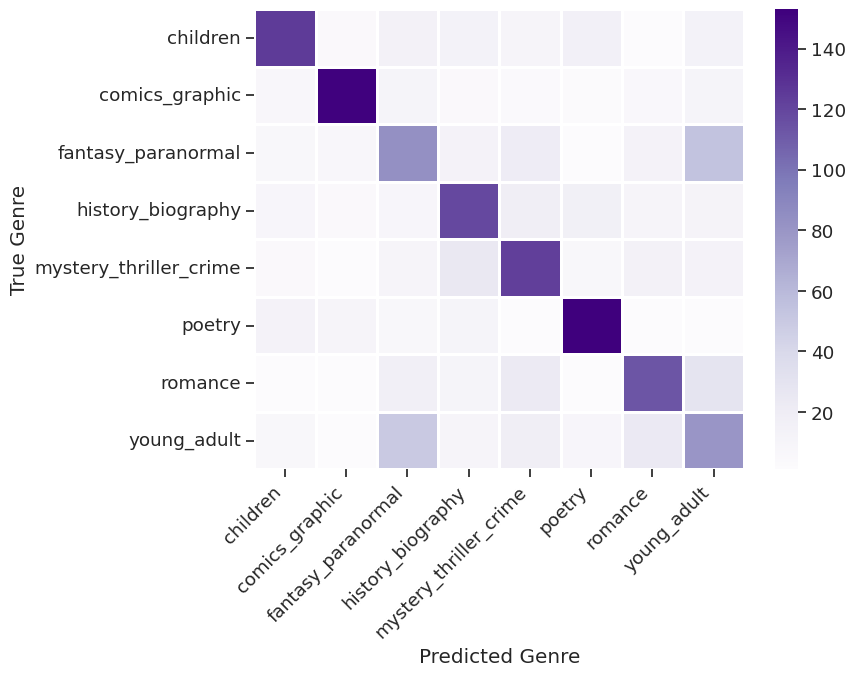

In [45]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [46]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

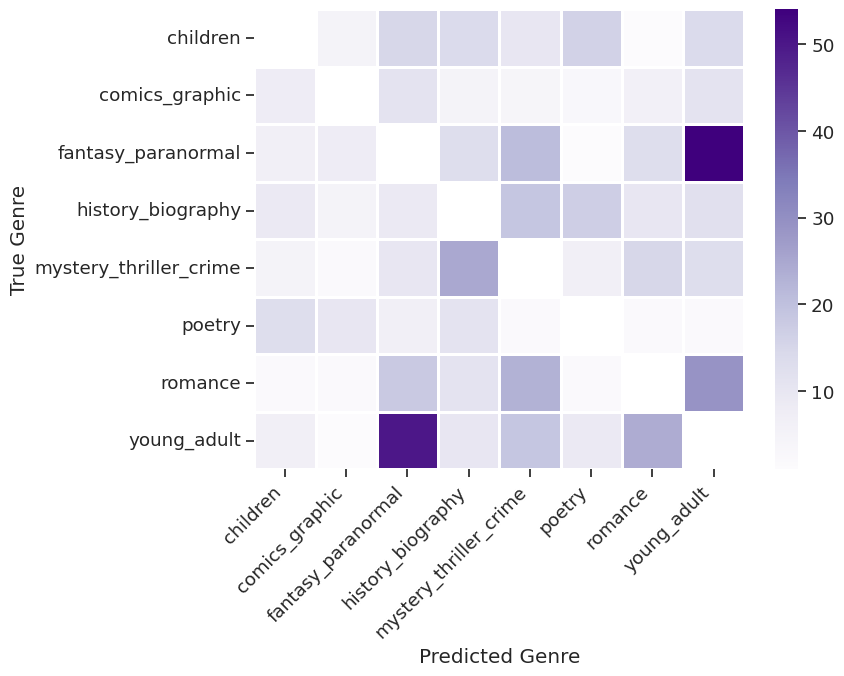

In [47]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.

In [48]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# 1. Name the model we want to borrow
model_name = 'distilbert-base-cased'
max_length = 512

# 2. Load the Tokenizer (The part that turns words into numbers for the AI)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

# 3. Load the Model (The actual brain)
# Note: id2label should already be defined in your starter notebook from Task 1!
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(id2label) 
).to("cuda") # "cuda" moves it to the Kaggle GPU!

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
import os
import wandb
from kaggle_secrets import UserSecretsClient
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# 1. Load Secrets Safely
secrets = UserSecretsClient()
os.environ['WANDB_API_KEY'] = secrets.get_secret('WANDB_API_KEY')
os.environ['HF_TOKEN'] = secrets.get_secret('HF_TOKEN')

# 2. Start your W&B Diary
wandb.init(
    project="mlops-assignment2",
    name="distilbert-kaggle-run",
    config={
        "model": model_name,
        "epochs": 3,
        "batch_size": 16,
        "learning_rate": 3e-5,
        "platform": "Kaggle",
    }
)

# 3. How do we grade the AI? (Accuracy and F1 Score)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

# 4. Set the Training Rules
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="wandb", # THIS IS THE MAGIC WORD THAT LOGS TO W&B!
    run_name="distilbert-kaggle-run",
)

# 5. Start Training!
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset, # Assuming starter notebook created this
    eval_dataset=test_dataset,   # Assuming starter notebook created this
    compute_metrics=compute_metrics,
)
trainer.train()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: g25ait2149 (g25ait2149-indian-institute-of-technology-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260521_142716-8lffw72s
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run distilbert-kaggle-run
wandb: ⭐️ View project at https://wandb.ai/g25ait2149-indian-institute-of-technology-jodhpur/mlops-assignment2
wandb: 🚀 View run at https://wandb.ai/g25ait2149-indian-institute-of-technology-jodhpur/mlops-assignment2/runs/8lffw72s
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.473866,2.406149,0.573750,0.572945
2,2.017265,2.328976,0.585625,0.587209
3,1.424426,2.394462,0.591875,0.594975


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=2.218538246154785, metrics={'train_runtime': 557.6963, 'train_samples_per_second': 34.427, 'train_steps_per_second': 1.076, 'total_flos': 2543646198988800.0, 'train_loss': 2.218538246154785, 'epoch': 3.0})

In [50]:
import json
from sklearn.metrics import classification_report

# 1. Run final test
eval_results = trainer.evaluate()
print(eval_results)

# 2. Save numbers to W&B
wandb.log({
    "final/loss": eval_results["eval_loss"],
    "final/accuracy": eval_results["eval_accuracy"],
    "final/f1": eval_results["eval_f1"],
})

# 3. Create a detailed text report
preds = trainer.predict(test_dataset).predictions.argmax(-1)
labels = [item["labels"].item() for item in test_dataset]
report = classification_report(
    labels, preds, target_names=list(id2label.values()), output_dict=True
)

# 4. Save the report to a file and upload it to W&B
with open("eval_report.json", "w") as f:
    json.dump(report, f, indent=2)

artifact = wandb.Artifact("eval-report", type="evaluation")
artifact.add_file("eval_report.json")
wandb.log_artifact(artifact)

# Tell W&B we are completely done
wandb.finish()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
1.424426,2.328976,3,0.585625,0.587209


{'eval_loss': 2.3289756774902344, 'eval_accuracy': 0.585625, 'eval_f1': 0.5872087415908505}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


wandb: uploading artifact eval-report; updating run metadata
wandb: uploading artifact eval-report
wandb: uploading history steps 18-18, summary
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▆█▆
wandb:                 eval/f1 ▁▆█▆
wandb:               eval/loss █▁▇▁
wandb:            eval/runtime ▄▁█▄
wandb: eval/samples_per_second ▅█▁▅
wandb:   eval/steps_per_second ▅█▁▄
wandb:          final/accuracy ▁
wandb:                final/f1 ▁
wandb:              final/loss ▁
wandb:           test/accuracy ▁
wandb:                     +10 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.58562
wandb:                 eval/f1 0.58721
wandb:               eval/loss 2.32898
wandb:            eval/runtime 14.5563
wandb: eval/samples_per_second 109.918
wandb:   eval/steps_per_second 1.717
wandb:          final/accuracy 0.58562
wandb:                final/f1 0.58721
wandb:              final/loss 2.32898
wandb:           test/accuracy 0.58562
wandb:                     +

In [51]:
from huggingface_hub import login

# Log in using the secret token we loaded earlier
login(token=os.environ['HF_TOKEN'])

# CHANGE "your-username" TO YOUR ACTUAL HUGGING FACE USERNAME!
my_repo = "g25ait2149/distilbert-goodreads-genres"

model.push_to_hub(my_repo)
tokenizer.push_to_hub(my_repo)

print(f"Model successfully uploaded to: https://huggingface.co/g25ait2149")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model successfully uploaded to: https://huggingface.co/g25ait2149
